# 06 · Unsupervised learning: PCA on yield curves and clustering companies

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/06_unsupervised_ml.ipynb)

**Goal:** reduce nine Treasury yields to three principal components (level, slope, curvature) and group
150 companies into data-driven peer groups with k-means and hierarchical clustering.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


## 1. PCA on monthly yield changes

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

yc = pd.read_csv(DATA + "treasury_yields.csv").set_index("month")
dy = yc.diff().dropna()            # PCA on changes, the usual choice for rates
pca = PCA().fit(dy)
ev = pd.DataFrame({"eigenvalue": pca.explained_variance_, "share": pca.explained_variance_ratio_,
                   "cumulative": pca.explained_variance_ratio_.cumsum()}, index=[f"PC{i+1}" for i in range(9)])
ev.round(4)

,eigenvalue,share,cumulative
PC1,0.4909,0.8932,0.8932
PC2,0.0373,0.0679,0.9611
PC3,0.0113,0.0205,0.9816
PC4,0.0023,0.0041,0.9858
PC5,0.0018,0.0033,0.9891
PC6,0.0017,0.0032,0.9922
PC7,0.0015,0.0027,0.9949
PC8,0.0015,0.0027,0.9976
PC9,0.0013,0.0024,1.0000


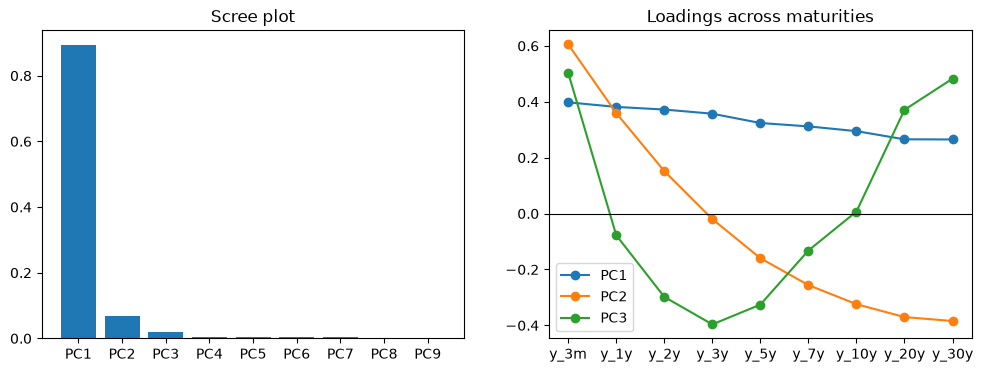

,PC1,PC2,PC3
y_3m,0.398,0.605,0.504
y_1y,0.382,0.359,-0.078
y_2y,0.372,0.152,-0.298
y_3y,0.357,-0.020,-0.397
y_5y,0.324,-0.160,-0.326
y_7y,0.312,-0.256,-0.132
y_10y,0.295,-0.324,0.007
y_20y,0.266,-0.370,0.371
y_30y,0.265,-0.384,0.483


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(ev.index, ev["share"]); ax[0].set_title("Scree plot")
load = pd.DataFrame(pca.components_[:3].T, index=dy.columns, columns=["PC1", "PC2", "PC3"])
load.plot(ax=ax[1], marker="o"); ax[1].axhline(0, color="k", lw=0.8); ax[1].set_title("Loadings across maturities")
plt.show()
load.round(3)

**Reading the loadings:** PC1 has the same sign at every maturity (a parallel shift = **level**),
PC2 changes sign from short to long (**slope**), PC3 is high at the ends and low in the middle (**curvature**).
Signs of components are arbitrary; flipping all of them changes nothing.

In [4]:
scores = pd.DataFrame(pca.transform(dy)[:, :3], columns=["PC1", "PC2", "PC3"], index=dy.index)
print(scores.corr().round(3))      # components are uncorrelated

     PC1  PC2  PC3
PC1  1.0 -0.0 -0.0
PC2 -0.0  1.0 -0.0
PC3 -0.0 -0.0  1.0


## 2. K-means on company fundamentals
Standardise first: P/E is in the tens, beta is around 1.

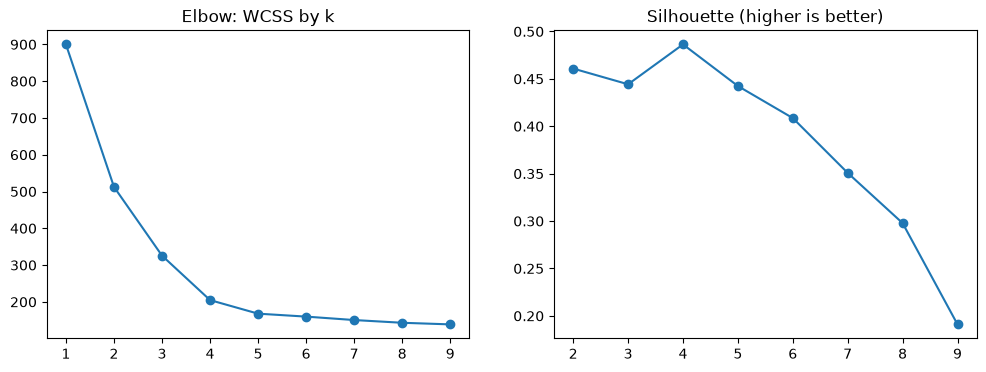

In [5]:
co = pd.read_csv(DATA + "company_fundamentals.csv")
feats = ["revenue_growth", "operating_margin", "pe_ratio", "dividend_yield", "beta", "debt_to_equity"]
Z = StandardScaler().fit_transform(co[feats])
wcss, sil = [], []
for k in range(1, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    wcss.append(km.inertia_); sil.append(silhouette_score(Z, km.labels_) if k > 1 else np.nan)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, 10), wcss, "o-"); ax[0].set_title("Elbow: WCSS by k")
ax[1].plot(range(1, 10), sil, "o-"); ax[1].set_title("Silhouette (higher is better)")
plt.show()

In [6]:
km = KMeans(n_clusters=5, n_init=10, random_state=0).fit(Z)
co["cluster"] = km.labels_
print(pd.crosstab(co["cluster"], co["true_sector"]))       # did clustering recover the sectors?
co.groupby("cluster")[feats].mean().round(2)

true_sector  banks  consumer_staples  energy  growth_tech  utilities
cluster                                                             
0                0                 1       0            0         29
1                0                 0       0           30          0
2               30                 0       0            0          0
3                0                 0      30            0          0
4                0                29       0            0          1


,revenue_growth,operating_margin,pe_ratio,dividend_yield,beta,debt_to_equity
cluster,,,,,,
0,0.25,18.75,15.61,3.91,0.53,1.53
1,21.83,25.29,37.80,0.45,1.36,0.29
2,6.93,31.66,10.52,2.94,1.10,2.43
3,7.08,11.44,9.41,4.56,1.24,0.74
4,4.68,16.57,23.12,2.61,0.67,0.80


## 3. Hierarchical (agglomerative) clustering and the dendrogram

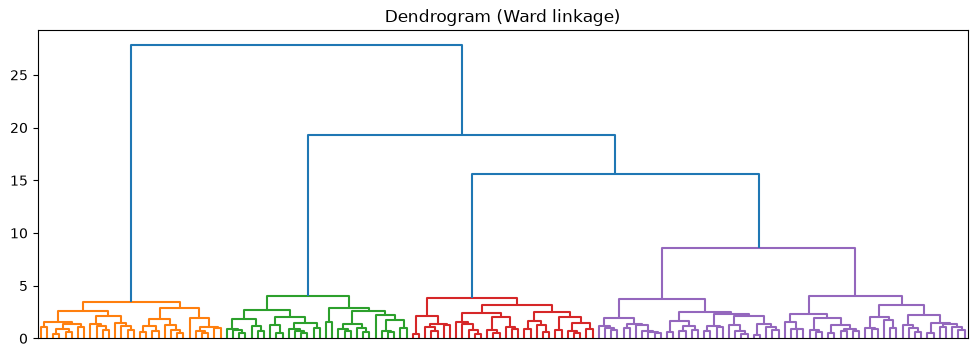

true_sector,banks,consumer_staples,energy,growth_tech,utilities
row_0,,,,,
0,30,0,0,0,0
1,0,0,30,0,0
2,0,1,0,0,29
3,0,0,0,30,0
4,0,29,0,0,1


In [7]:
Lk = linkage(Z, method="ward")
plt.figure(figsize=(12, 4)); dendrogram(Lk, no_labels=True, color_threshold=12); plt.title("Dendrogram (Ward linkage)"); plt.show()
agg = AgglomerativeClustering(n_clusters=5, linkage="ward").fit(Z)
pd.crosstab(agg.labels_, co["true_sector"])

### Exercise 1

How many principal components do you need to explain 95% of the variance in yield changes? Store the number in `n_pc_95`.

In [8]:
# Your code here

In [9]:
check("06.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 06.1: not answered yet. Store your answer in `n_pc_95`.


### Exercise 2

Run PCA on the **companies** (standardised, i.e. on `Z`). Store the share of variance explained by the first two components in `share_2pc`, then plot the companies on PC1 vs PC2 coloured by `true_sector`.

In [10]:
# Your code here

In [11]:
check("06.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 06.2: not answered yet. Store your answer in `share_2pc`.


### Exercise 3

Run k-means with k = 3 instead of 5 (`n_init=10, random_state=0`). Store the set of sectors that end up in the same cluster as energy in `merged_with_energy`, e.g. `{'energy', 'banks'}`. Does the grouping make economic sense?

In [12]:
# Your code here

In [13]:
check("06.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 06.3: not answered yet. Store your answer in `merged_with_energy`.


---
## Solutions

1) 2 components
2) first two PCs explain 74.3%


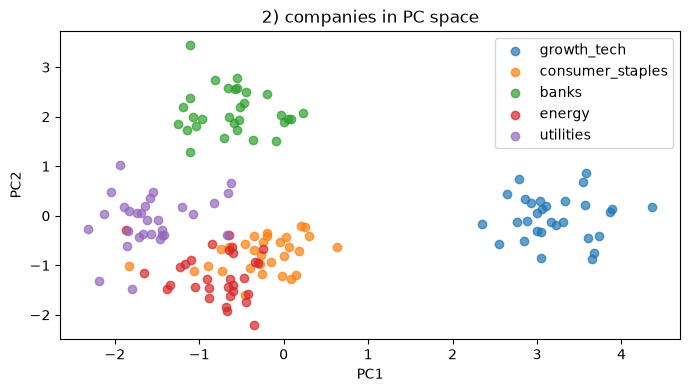

3)
true_sector  banks  consumer_staples  energy  growth_tech  utilities
row_0                                                               
0                0                 0       0           30          0
1                0                30      30            0         29
2               30                 0       0            0          1
merged with energy: {'utilities', 'energy', 'consumer_staples'}
✅ Exercise 06.1: correct.
✅ Exercise 06.2: correct.
✅ Exercise 06.3: correct.

3 of 3 exercises correct.


In [14]:
n_pc_95 = int((ev["cumulative"] < 0.95).sum() + 1)
print("1)", n_pc_95, "components")
pca2 = PCA(2).fit(Z); share_2pc = pca2.explained_variance_ratio_.sum(); pc = pca2.transform(Z)
print(f"2) first two PCs explain {share_2pc:.1%}")
for s in co["true_sector"].unique():
    msk = co["true_sector"] == s; plt.scatter(pc[msk, 0], pc[msk, 1], label=s, alpha=0.7)
plt.legend(); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("2) companies in PC space"); plt.show()
lab3 = KMeans(3, n_init=10, random_state=0).fit_predict(Z)
tab3 = pd.crosstab(lab3, co["true_sector"]); print("3)"); print(tab3)
major = tab3.idxmax()                       # each sector's main cluster
merged_with_energy = set(major[major == major["energy"]].index); print("merged with energy:", merged_with_energy)
check_all("06")